In [ ]:
import fcla as fc
model = "qwen3:4b"
fc.test_llm()

FCLAgent class successfully compiled.
That's an excellent question, but **there is no widely recognized or standard organization called "FCNA" that operates as an "agent" in major global contexts (finance, law, real estate, etc.)**. This is likely due to a **typo, misunderstanding of an acronym, or confusion with a similar-sounding term**.

Here's a breakdown of the most probable explanations and what you might actually be referring to:

---

### ✅ 1. **Most Likely: You meant "FCA" (Financial Conduct Authority)**
   - **What it is**: The **FCA** is the UK's financial regulator (part of the UK's Financial Conduct Authority). It oversees financial services, markets, and protects consumers.
   - **FCA Agent**: In the UK, an **FCA-authorised agent** is a person/organization that acts on behalf of clients in regulated financial activities (e.g., trading, investments, insurance). They must be approved by the FCA.
   - **Why this fits**: "FCNA" is very close to "FCA" (a common typo if you mis

# Simulations

## 1) Simulation withouth llms 

In [8]:
# CELDA 3: Ejecución de la Simulación
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from pams.runners.sequential import SequentialRunner
from pams.logs.market_step_loggers import MarketStepSaver

# Ignorar las advertencias de redondeo del tick size para limpiar la consola
warnings.filterwarnings("ignore", category=UserWarning, module="pams.market")

# 1. Configurar el Logger
#Saves the steps of the simulation
market_logger = MarketStepSaver()

# 2.Initialize the runner
# The runner is the one in charge of simulation control
runner = SequentialRunner(
    settings="./jsons/config.json",
    logger=market_logger
)

# 3. Runs the simulation with 500 steps
print("Iniciando la simulación base (Escenario Fase 2)...")
runner.main()
print("Simulación terminada con éxito.")

# 4. Extracts and saves the data on a new Data Frame
datos_log = market_logger.market_step_logs
df_precios = pd.DataFrame(datos_log)
df_precios.to_csv("./results/base_results_fcn.csv", index=False)
print("Data saved on './results/base_results_fcn.csv'")

Iniciando la simulación base (Escenario Fase 2)...
# INITIALIZATION TIME 0.2201246
# EXECUTION TIME 0.6892723
Simulación terminada con éxito.
Data saved on './results/base_results_fcn.csv'


Columnas exportadas por PAMS: ['session_id', 'market_time', 'market_id', 'market_name', 'market_price', 'fundamental_price']


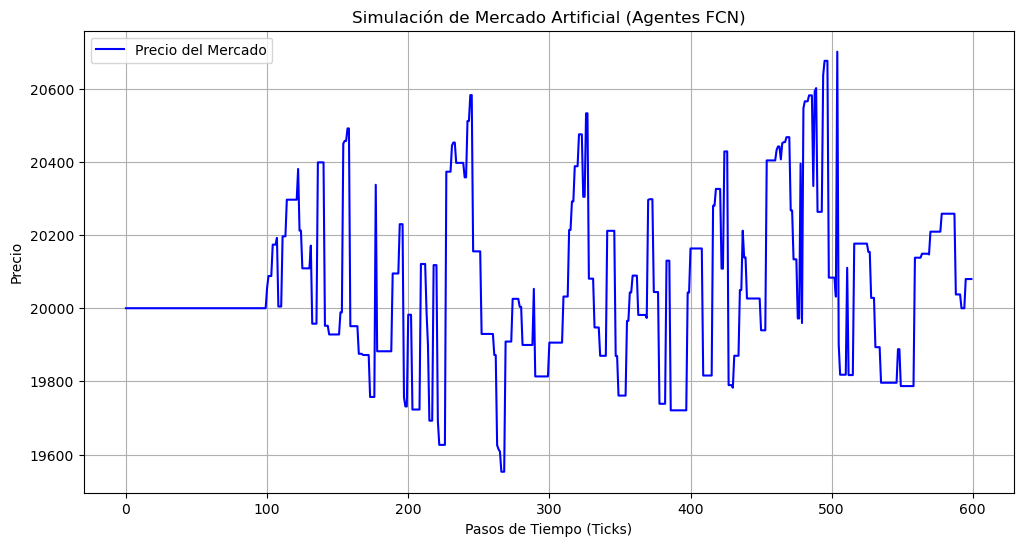

In [10]:


df = pd.read_csv("./results/base_results_fcn.csv")

# Prints the data to see the exported data
print("Columnas exportadas por PAMS:", df.columns.tolist())

# PAMS tends to saves the time 'market_time'.
#We use the index of the table in case there's a name conflict
tiempo = df['market_time'] if 'market_time' in df.columns else df.index

# Graph the market price on the elapsed time
plt.figure(figsize=(12, 6))
plt.plot(tiempo, df['market_price'], label="Precio del Mercado", color='blue')
plt.title("Simulación de Mercado Artificial (Agentes FCN)")
plt.xlabel("Pasos de Tiempo (Ticks)")
plt.ylabel("Precio")
plt.legend()
plt.grid(True)
plt.show()

## 2) Simulation with llms

In [1]:
import fcla as fc
import pandas as pd
from pams.runners.sequential import SequentialRunner
from pams.logs.market_step_loggers import MarketStepSaver
# 1. Initialize the Logger
model = "qwen3:4b"
logger = MarketStepSaver()
runner = SequentialRunner(settings="./jsons/agenticConfig.json",logger=logger)
runner.class_register(fc.FCLAgent)
model = "qwen3.5:4b"
# 4. Execute the Simulation
print("Starting Hybrid Simulation (FCNAgents + FCLAgents)...")
runner.main()
print("Simulation complete.")
df_results = pd.DataFrame(logger.market_step_logs)
df_results.to_csv("./results/llm_hybrid_market_results.csv", index=False)

FCLAgent class successfully compiled.
Starting Hybrid Simulation (FCNAgents + FCLAgents)...
Error local en Ollama: model 'qwen2.5:3b' not found (status code: 404)
Error local en Ollama: model 'qwen2.5:3b' not found (status code: 404)
Error local en Ollama: model 'qwen2.5:3b' not found (status code: 404)
Error local en Ollama: model 'qwen2.5:3b' not found (status code: 404)
Error local en Ollama: model 'qwen2.5:3b' not found (status code: 404)
Error local en Ollama: model 'qwen2.5:3b' not found (status code: 404)
Error local en Ollama: model 'qwen2.5:3b' not found (status code: 404)
Error local en Ollama: model 'qwen2.5:3b' not found (status code: 404)
# INITIALIZATION TIME 0.0
# EXECUTION TIME 0.1250599
Simulation complete.


c:\Users\alejo\anaconda3\envs\ai\Lib\site-packages\pams\market.py:759: UserWarning: order price does not accord to the tick size. price will be modified
  warnings.warn(


visualización 

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("./results/llm_hybrid_market_results.csv")
plt.figure(figsize=(14, 7))
# 4. Graficar la evolución del precio de mercado y el precio fundamental a lo largo del tiempo
plt.plot(df['market_time'], df['market_price'],
         label='Precio de Mercado (Híbrido: Algoritmos + LLM)',
         color='#1f77b4', linewidth=1.5)
plt.plot(df['market_time'], df['fundamental_price'],
         label='Precio Fundamental (P_F)',
         color='#d62728', linestyle='--', linewidth=1.5)
plt.axhline(y=10.50, color='#2ca02c', linestyle=':', linewidth=2,
            label='Punto de Referencia LLM (10.50)')
plt.axvspan(0, 100, color='gray', alpha=0.2, label='Fase de Calentamiento (Sin Ejecución)')
plt.title('Evolución del Precio en Mercado Artificial Híbrido (Agentes LLM con Aversión a la Pérdida)', fontsize=15)
plt.xlabel('Tiempo de Mercado (Ticks)', fontsize=12)
plt.ylabel('Precio del Activo', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:

print("\n" + "="*40)
print("📊 RESUMEN ESTADÍSTICO DE LA SIMULACIÓN")
print("="*40)
# Filtramos solo la Sesión 1 (donde hubo trading real)
df_real = df[df['market_time'] > 100]

print(f"▶ Precio Inicial:        {df_real['market_price'].iloc[0]:.4f}")
print(f"▶ Precio Final:          {df_real['market_price'].iloc[-1]:.4f}")
print(f"▶ Precio Máximo (Pico):  {df_real['market_price'].max():.4f}")
print(f"▶ Precio Mínimo (Caída): {df_real['market_price'].min():.4f}")
print(f"▶ Volatilidad (Desv. E): {df_real['market_price'].std():.4f}")
print("="*40)

 Análisis de Comportamiento Individual de Órdenes

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
# 1. Extraer los logs de las órdenes individuales (no del mercado general)
order_logs = runner.logger.order_logs
df_orders = pd.DataFrame(order_logs)
# 2. Limpiar los datos
# Filtramos la Sesión 1 y eliminamos las órdenes a mercado (precio 0 o nulo)
df_real_orders = df_orders[(df_orders['session_id'] == 1) & (df_orders['price'] > 0)].copy()
# 3. Separar a los agentes por su ID
df_algo = df_real_orders[df_real_orders['agent_id'] <= 95]
df_llm = df_real_orders[df_real_orders['agent_id'] > 95]
# 4. Configurar la gráfica
plt.figure(figsize=(14, 7))
# 5. Graficar las órdenes Algorítmicas (Fondo)
plt.scatter(df_algo['market_time'], df_algo['price'],
            color='#1f77b4', alpha=0.3, s=15,
            label='Intenciones Algorítmicas (FCN puros)')
# 6. Graficar las órdenes del LLM (Frente)
plt.scatter(df_llm['market_time'], df_llm['price'],
            color='#d62728', alpha=0.9, s=60, marker='X',
            label='Intenciones LLM (Sesgo Cognitivo)')
# 7. Línea de Referencia
plt.axhline(y=10.50, color='#2ca02c', linestyle=':', linewidth=2,
            label='Punto de Referencia LLM (10.50)')
plt.title('Microestructura: Precios de Órdenes Colocadas (Algoritmos vs LLMs)', fontsize=15)
plt.xlabel('Tiempo de Mercado (Ticks)', fontsize=12)
plt.ylabel('Precio de la Orden Colocada', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
